In [38]:
pip install pandas openpyxl

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd

<h3>Importing and converting excel file to our DataFrame</h3>

In [4]:
df = pd.read_excel("D:\QuickHyre AI\Forecasting Case- Study.xlsx")
df.head()

,State,Date,Total,Category
0,Alabama,2019-01-12 00:00:00,109574036.0,Beverages
1,Arizona,2019-01-12 00:00:00,109101594.6,Beverages
2,Arkansas,2019-01-12 00:00:00,58049432.2,Beverages
3,California,2019-01-12 00:00:00,444766890.6,Beverages
4,Colorado,2019-01-12 00:00:00,89816716.3,Beverages


In [4]:
df.columns

Index(['State', 'Date', 'Total', 'Category'], dtype='object')

<h4>Finding the unique set of states that are repeating themselves over a time.</h4>

In [5]:
df['State'].unique()

array(['Alabama', 'Arizona', 'Arkansas', 'California', 'Colorado',
       'Connecticut', 'Florida', 'Georgia', 'Illinois', 'Indiana', 'Iowa',
       'Kansas', 'Kentucky', 'Louisiana', 'Maine', 'Maryland',
       'Massachusetts', 'Michigan', 'Minnesota', 'Mississippi',
       'Missouri', 'Nebraska', 'Nevada', 'New Hampshire', 'New Mexico',
       'New York', 'North Carolina', 'Ohio', 'Oklahoma', 'Oregon',
       'Pennsylvania', 'Rhode Island', 'South Carolina', 'South Dakota',
       'Tennessee', 'Texas', 'Utah', 'Vermont', 'Virginia', 'Washington',
       'West Virginia', 'Wisconsin', 'Wyoming'], dtype=object)

<h4>Checking if there are different formats of dates being used. </h4>

In [23]:
unique_date = df['Date'].unique()
for i in unique_date:
    print(i)
    

2019-01-12 00:00:00
2019-03-11 00:00:00
2019-06-10 00:00:00
2019-08-12 00:00:00
2019-10-11 00:00:00
2020-01-03 00:00:00
2020-01-11 00:00:00
2020-02-02 00:00:00
2020-02-08 00:00:00
2020-03-05 00:00:00
2020-04-10 00:00:00
2020-05-01 00:00:00
2020-05-04 00:00:00
2020-05-07 00:00:00
2020-06-09 00:00:00
2020-06-12 00:00:00
2020-07-06 00:00:00
2020-08-03 00:00:00
2020-08-11 00:00:00
2020-09-02 00:00:00
2020-09-08 00:00:00
2020-10-05 00:00:00
2020-11-10 00:00:00
2020-12-01 00:00:00
2020-12-04 00:00:00
2020-12-07 00:00:00
2021-01-08 00:00:00
2021-02-05 00:00:00
2021-03-01 00:00:00
2021-03-10 00:00:00
2021-04-04 00:00:00
2021-04-07 00:00:00
2021-05-09 00:00:00
2021-05-12 00:00:00
2021-06-06 00:00:00
2021-07-02 00:00:00
2021-07-03 00:00:00
2021-07-11 00:00:00
2021-08-08 00:00:00
2021-09-05 00:00:00
2021-10-01 00:00:00
2021-10-10 00:00:00
2021-11-04 00:00:00
2021-11-07 00:00:00
2021-12-09 00:00:00
2021-12-12 00:00:00
2022-01-05 00:00:00
2022-02-01 00:00:00
2022-02-10 00:00:00
2022-03-04 00:00:00


<h3>STEP 1: Converting the diffrent date format to a single standardized date format, i.e. YYYY-MM-dd 00:00:00 </h3>

In [5]:
df['date'] = pd.to_datetime(
    df['Date'],
    dayfirst =True,
    errors = "coerce"
    )

In [6]:
for i in df['date'].unique():
    print(i)

2019-01-12 00:00:00
2019-03-11 00:00:00
2019-06-10 00:00:00
2019-08-12 00:00:00
2019-10-11 00:00:00
2020-01-03 00:00:00
2020-01-11 00:00:00
2020-02-02 00:00:00
2020-02-08 00:00:00
2020-03-05 00:00:00
2020-04-10 00:00:00
2020-05-01 00:00:00
2020-05-04 00:00:00
2020-05-07 00:00:00
2020-06-09 00:00:00
2020-06-12 00:00:00
2020-07-06 00:00:00
2020-08-03 00:00:00
2020-08-11 00:00:00
2020-09-02 00:00:00
2020-09-08 00:00:00
2020-10-05 00:00:00
2020-11-10 00:00:00
2020-12-01 00:00:00
2020-12-04 00:00:00
2020-12-07 00:00:00
2021-01-08 00:00:00
2021-02-05 00:00:00
2021-03-01 00:00:00
2021-03-10 00:00:00
2021-04-04 00:00:00
2021-04-07 00:00:00
2021-05-09 00:00:00
2021-05-12 00:00:00
2021-06-06 00:00:00
2021-07-02 00:00:00
2021-07-03 00:00:00
2021-07-11 00:00:00
2021-08-08 00:00:00
2021-09-05 00:00:00
2021-10-01 00:00:00
2021-10-10 00:00:00
2021-11-04 00:00:00
2021-11-07 00:00:00
2021-12-09 00:00:00
2021-12-12 00:00:00
2022-01-05 00:00:00
2022-02-01 00:00:00
2022-02-10 00:00:00
2022-03-04 00:00:00


<h4>Dropping the old Date column and checking the new set of columns</h4>

In [7]:
df = df.drop("Date", axis=1)

In [8]:
df.columns

Index(['State', 'Total', 'Category', 'date'], dtype='object')

In [9]:
df['Year'] = df['date'].dt.year

In [46]:
df.columns

Index(['State', 'Total', 'Category', 'date', 'Year'], dtype='object')

<h3>STEP 2: Sort Properly</h3>

In [55]:
df= df.sort_values(['State','date'])

In [56]:
df.head()

,State,Total,Category,date,Year,Month
0,Alabama,109574036.0,Beverages,2019-01-12,2019,1
43,Alabama,112189103.8,Beverages,2019-03-11,2019,3
86,Alabama,129106730.4,Beverages,2019-06-10,2019,6
129,Alabama,108083723.8,Beverages,2019-08-12,2019,8
172,Alabama,110932912.8,Beverages,2019-10-11,2019,10


In [57]:
df['date'].dt.day_name().value_counts()

date
Sunday       5375
Friday        688
Monday        473
Tuesday       473
Saturday      430
Wednesday     344
Thursday      301
Name: count, dtype: int64

<h3>Step:3 Create Fully Weekly Timeline</h3>

In [58]:
full_dates = pd.date_range(
    start=df['date'].min(),
    end=df['date'].max(),
    freq='W-SUN
)

In [59]:
print(full_dates)

DatetimeIndex(['2019-01-13', '2019-01-20', '2019-01-27', '2019-02-03',
               '2019-02-10', '2019-02-17', '2019-02-24', '2019-03-03',
               '2019-03-10', '2019-03-17',
               ...
               '2023-10-01', '2023-10-08', '2023-10-15', '2023-10-22',
               '2023-10-29', '2023-11-05', '2023-11-12', '2023-11-19',
               '2023-11-26', '2023-12-03'],
              dtype='datetime64[ns]', length=256, freq='W-SUN')


<h3>Step 4: Reindex Each State</h3>

In [61]:
final_dfs = []

for state in df['State'].unique():

    temp = df[df['State'] == state].copy()

    temp = temp.set_index('date')

    temp = temp.reindex(full_dates)

    temp['State'] = state

    final_dfs.append(temp)

df_final = pd.concat(final_dfs)

<h3>Restore Date Column </h3>

In [64]:
df_final = df_final.reset_index()

df_final.rename(columns={'index': 'Date'}, inplace=True)

In [66]:
df_final

,Date,Date,State,Total,Category,Year,Month
0,0,2019-01-13,Alabama,NaN,NaN,NaN,NaN
1,1,2019-01-20,Alabama,NaN,NaN,NaN,NaN
2,2,2019-01-27,Alabama,NaN,NaN,NaN,NaN
3,3,2019-02-03,Alabama,NaN,NaN,NaN,NaN
4,4,2019-02-10,Alabama,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
11003,11003,2023-11-05,Wyoming,NaN,NaN,NaN,NaN
11004,11004,2023-11-12,Wyoming,NaN,NaN,NaN,NaN
11005,11005,2023-11-19,Wyoming,NaN,NaN,NaN,NaN
11006,11006,2023-11-26,Wyoming,NaN,NaN,NaN,NaN


In [67]:
df_final.to_excel("df_final.xlsx", index=False)

<h3>STEP 6: Interpolate Missing Sales</h3>

In [68]:
df_final['Total'] = df_final.groupby('State')['Total']\
    .transform(lambda x: x.interpolate(method='linear'))

In [73]:
df_final.isnull().sum()

Date           0
Date           0
State          0
Total       1677
Category    5633
Year        5633
Month       5633
dtype: int64

In [76]:
df_final.columns

Index(['Date', 'Date', 'State', 'Total', 'Category', 'Year', 'Month'], dtype='object')

In [78]:
df_final['Total'] = df_final.groupby('State')['Total']\
    .transform(lambda x: x.bfill().ffill())

In [80]:
df_final.isnull().sum()

Date           0
Date           0
State          0
Total          0
Category    5633
Year        5633
Month       5633
dtype: int64

In [87]:
df_final['Category']=df_final['Category'].fillna('Beverages')

In [88]:
df_final.isnull().sum()

Date           0
Date           0
State          0
Total          0
Category       0
Year        5633
Month       5633
dtype: int64

In [95]:
df_final=df_final.drop(['Year','Month'],axis=1)

In [101]:
df_final.head()

,Date,Date,State,Total,Category
0,0,2019-01-13,Alabama,123782285.8,Beverages
1,1,2019-01-20,Alabama,123782285.8,Beverages
2,2,2019-01-27,Alabama,123782285.8,Beverages
3,3,2019-02-03,Alabama,123782285.8,Beverages
4,4,2019-02-10,Alabama,123782285.8,Beverages


In [107]:
df_final = df_final.loc[:, ~df_final.columns.duplicated(keep='last')]

In [108]:
df_final.head()

,Date,State,Total,Category
0,2019-01-13,Alabama,123782285.8,Beverages
1,2019-01-20,Alabama,123782285.8,Beverages
2,2019-01-27,Alabama,123782285.8,Beverages
3,2019-02-03,Alabama,123782285.8,Beverages
4,2019-02-10,Alabama,123782285.8,Beverages


In [109]:
df_final.to_excel("Data_processed_file.xlsx", index=False)

<h2>Feature Engineering</h2>

<h3>Step1: Sort Data Properly<h3>

In [154]:
df_final=df_final.sort_values(['State','Date'])

<h3>Step2: Lag Features</h3>
<p>Lags for Weekly Data Feature Meaning<br>
lag_1	previous week<br>
lag_4	previous month<br>
lag_12	previous quarter</p>

In [155]:
df_final['lag_1'] = (
    df_final.groupby('State')['Total'].shift(1)
)

df_final['lag_7'] = (
    df_final.groupby('State')['Total'].shift(7)
)

df_final['lag_30'] = (
    df_final.groupby('State')['Total'].shift(30)
)

<h3>STEP 3: Rolling Mean & Std</h3>

Rolling Mean

In [156]:
df_final['rolling_mean_4'] = (
    df_final.groupby('State')['Total']
    .transform(lambda x: x.rolling(window=4).mean())
)

<p>Rolling Standard</p>

In [157]:
df_final['rolling_std_4'] = (
    df_final.groupby('State')['Total']
    .transform(lambda x: x.rolling(window=4).std())
)

<h3>STEP 4: Day of Week</h3>

In [158]:
df_final['day_of_week'] = df_final['Date'].dt.dayofweek

<h3>STEP 5: Month Feature</h3>

In [159]:
df_final['month'] = df_final['Date'].dt.month

<h3>STEP 6: Quarter (BONUS FEATURE)</h3>

In [160]:
df_final['quarter'] = df_final['Date'].dt.quarter

<h3>STEP 7: Week of Year (VERY GOOD FEATURE)</h3>

In [118]:
df_final['week_of_year'] = (
    df_final['Date'].dt.isocalendar().week.astype(int)
)

<h3>STEP 7.1: Year </h3>

In [161]:
df_final['year'] = df_final['Date'].dt.year

<h3>STEP 8: Holiday Flag</h3>

In [162]:
pip install holidays

Note: you may need to restart the kernel to use updated packages.


In [163]:
import holidays

us_holidays = holidays.US()

Holiday Flag Column

In [164]:
df_final['is_holiday'] = (
    df_final['Date']
    .isin(us_holidays)
    .astype(int)
)

<h3>STEP 9 — Cyclical Encoding (VERY PROFESSIONAL)</h3>

In [165]:
import numpy as np

df_final['month_sin'] = np.sin(
    2 * np.pi * df_final['month'] / 12
)

df_final['month_cos'] = np.cos(
    2 * np.pi * df_final['month'] / 12
)

<h3>STEP 10 — Remove NaNs Generated by Lag Features</h3>

In [166]:
df_final = df_final.dropna()

<h2>Time-Series Train/Validation Split</h2>

In [167]:
df_final = df_final.sort_values(['State', 'Date'])

<h3>STEP 2: Chronological Split</h3>

In [168]:
train_df = df_final[df_final['Date'] < '2023-01-01']

val_df = df_final[df_final['Date'] >= '2023-01-01']

Verify Split

In [169]:
print(train_df['Date'].min(), train_df['Date'].max())

print(val_df['Date'].min(), val_df['Date'].max())

2020-03-08 00:00:00 2022-12-25 00:00:00
2023-01-01 00:00:00 2023-12-03 00:00:00


<h3>STEP 3: Define Features</h3>

<h3>State Enoding</h3>

In [170]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df_final['state_encoded'] = (
    le.fit_transform(df_final['State'])
)

In [171]:
FEATURES = [
    'lag_1',
    'lag_7',
    'lag_30',
    'rolling_mean_4',
    'rolling_std_4',
    'day_of_week',
    'month',
    'quarter',
    'week_of_year',
    'year',
    'month_sin',
    'month_cos',
    'is_holiday',
    'state_encoded'
]

<h3>STEP 4: Create X & y</h3>

In [172]:
X_train = train_df[FEATURES]

y_train = train_df['Total']

X_val = val_df[FEATURES]

y_val = val_df['Total']

<h3>STEP 5: Train XGBoost</h3>

In [173]:
pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
    --------------------------------------- 2.1/101.7 MB 10.7 MB/s eta 0:00:10
   - -------------------------------------- 4.2/101.7 MB 10.5 MB/s eta 0:00:10
   -- ------------------------------------- 5.5/101.7 MB 9.6 MB/s eta 0:00:11
   -- ------------------------------------- 6.8/101.7 MB 8.6 MB/s eta 0:00:12
   --- ------------------------------------ 8.1/101.7 MB 7.9 MB/s eta 0:00:12
   --- ------------------------------------ 10.0/101.7 MB 8.3 MB/s eta 0:00:12
   ---- ----------------------------------- 11.3/101.7 MB 8.1 MB/s eta 0:00:12
   ---- ----------------------------------- 12.1/101.7 MB 7.4 MB/s eta 0:00:13
   ---- ----------------------------------- 12.6/101.7 MB 6.9 MB/s eta 0:00:13
   ----- ---------------------------------- 13.1/101.7 MB 6.5 MB/s eta 0:00:14
   ----- ---------------------------------- 13.6/101.7 MB 6.0 MB/s eta 0:00:15
   ----- ---------------------------------- 14.2/101.7 MB 5.8 M

In [174]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


<h3>STEP 6: Predictions</h3>

In [175]:
xgb_preds = xgb_model.predict(X_val)

<h3>STEP 7: Evaluation</h3>

RMSE

In [176]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

import numpy as np

rmse = np.sqrt(
    mean_squared_error(y_val, xgb_preds)
)

print("RMSE:", rmse)

RMSE: 7183823.978061673


MAE

In [177]:
mae = mean_absolute_error(y_val, xgb_preds)

print("MAE:", mae)

MAE: 3265599.821652352


<h3>Visualization</h3>

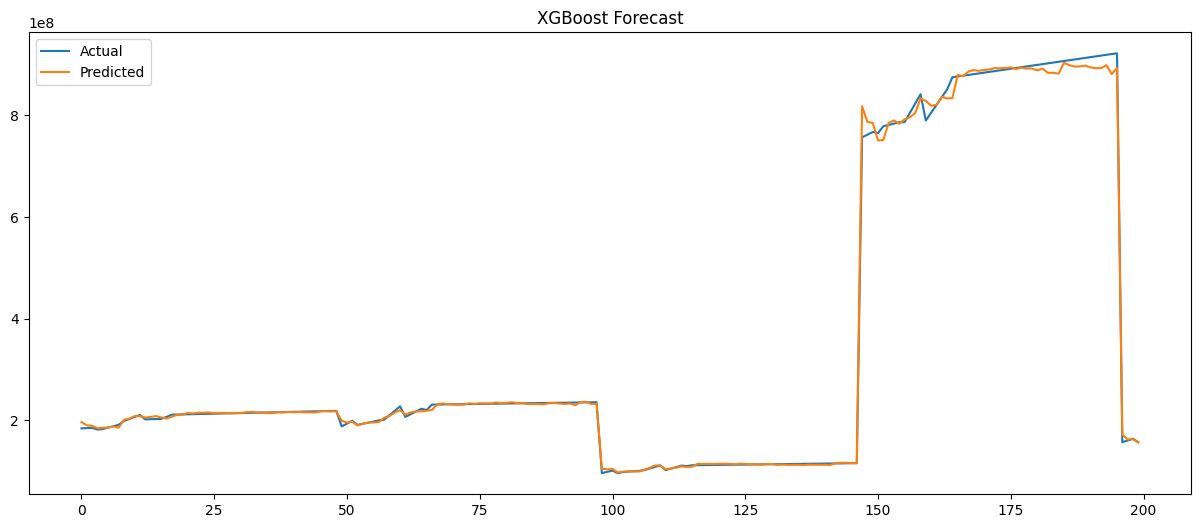

In [178]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

plt.plot(
    y_val.values[:200],
    label='Actual'
)

plt.plot(
    xgb_preds[:200],
    label='Predicted'
)

plt.legend()

plt.title("XGBoost Forecast")

plt.show()

<h2>MODEL 2: PROPHET</h2>

In [179]:
pip install prophet

   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ----- ---------------------------------- 1.6/12.1 MB 8.4 MB/s eta 0:00:02
   ----------- ---------------------------- 3.4/12.1 MB 8.4 MB/s eta 0:00:02
   ------------------ --------------------- 5.5/12.1 MB 9.1 MB/s eta 0:00:01
   ------------------------- -------------- 7.6/12.1 MB 9.4 MB/s eta 0:00:01
   -------------------------------- ------- 9.7/12.1 MB 9.6 MB/s eta 0:00:01
   ---------------------------------------  12.1/12.1 MB 9.9 MB/s eta 0:00:01
   ---------------------------------------- 12.1/12.1 MB 9.7 MB/s  0:00:01

   ---------- ----------------------------- 1/4 [importlib_resources]
   ---------- ----------------------------- 1/4 [importlib_resources]
   -------------------- ------------------- 2/4 [cmdstanpy]
   -------------------- ------------------- 2/4 [cmdstanpy]
   -------------------- ------------------- 2/4 [cmdstanpy]
   ------------------------------ --------- 3/4 [prophet]
   ----------

<h3>STEP 1: Create Prophet Dataset</h3>

In [180]:
state_name = 'Alabama'

state_df = df_final[
    df_final['State'] == state_name
].copy()

In [182]:
prophet_df = state_df[['Date', 'Total']]

prophet_df.columns = ['ds', 'y']

<h3>STEP 2: Train/Validation Split</h3>

In [183]:
train_prophet = prophet_df[
    prophet_df['ds'] < '2023-01-01'
]

val_prophet = prophet_df[
    prophet_df['ds'] >= '2023-01-01'
]

<h3>STEP 3: Train Prophet</h3>

In [184]:
from prophet import Prophet

prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

prophet_model.fit(train_prophet)

Importing plotly failed. Interactive plots will not work.
16:04:37 - cmdstanpy - INFO - Chain [1] start processing
16:04:37 - cmdstanpy - INFO - Chain [1] done processing


<h3>STEP 4: Forecast Validation Period</h3>

In [185]:
future = val_prophet[['ds']]

forecast = prophet_model.predict(future)

<h3>STEP 5: Predictions</h3>

In [186]:
prophet_preds = forecast['yhat'].values

<h3>STEP 6: Evaluate</h3>

In [187]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

import numpy as np

prophet_rmse = np.sqrt(
    mean_squared_error(
        val_prophet['y'],
        prophet_preds
    )
)

prophet_mae = mean_absolute_error(
    val_prophet['y'],
    prophet_preds
)

print("Prophet RMSE:", prophet_rmse)

print("Prophet MAE:", prophet_mae)

Prophet RMSE: 10389973.28860957
Prophet MAE: 8996128.9747827


<h3>Visualisation</h3>

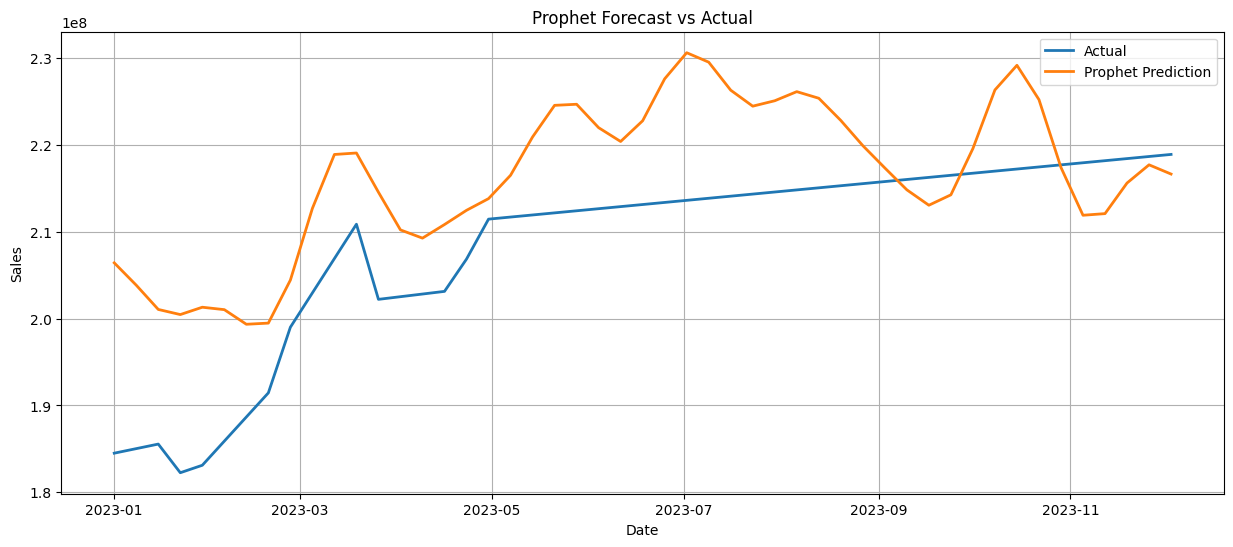

In [206]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

plt.plot(
    val_prophet['ds'],
    val_prophet['y'],
    label='Actual',
    linewidth=2
)

plt.plot(
    val_prophet['ds'],
    prophet_preds,
    label='Prophet Prediction',
    linewidth=2
)

plt.title('Prophet Forecast vs Actual')

plt.xlabel('Date')

plt.ylabel('Sales')

plt.legend()

plt.grid(True)

plt.show()

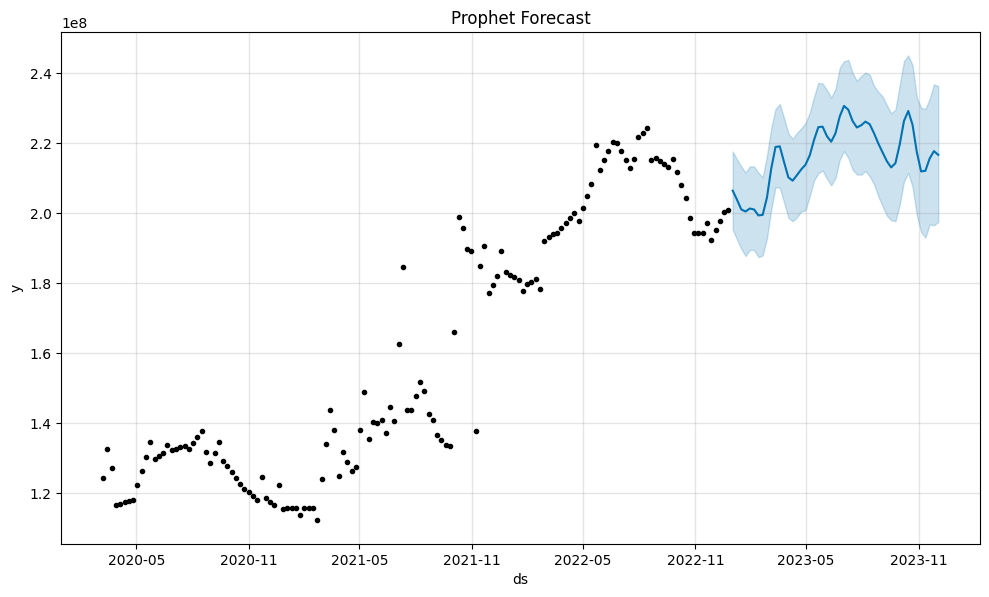

In [207]:
prophet_model.plot(forecast)

plt.title("Prophet Forecast")

plt.show()

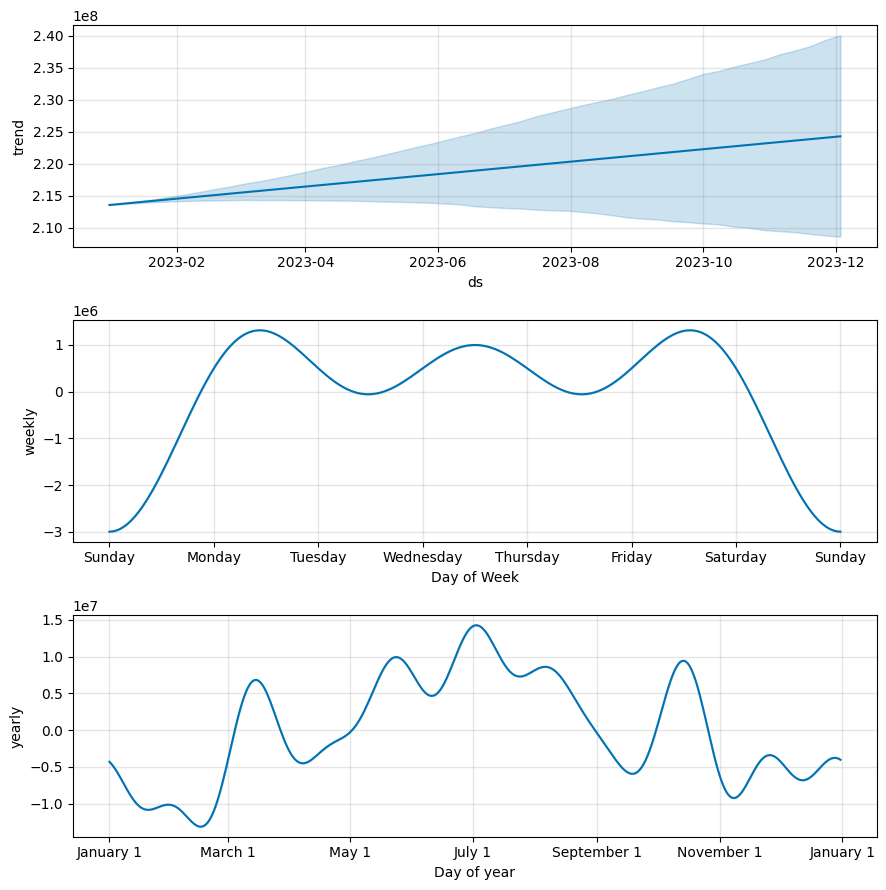

In [208]:
prophet_model.plot_components(forecast)

plt.show()

<h2>MODEL 3: ARIMA / SARIMA</h2>

In [188]:
pip install statsmodels

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ----- ---------------------------------- 1.3/9.6 MB 7.4 MB/s eta 0:00:02
   ---------- ----------------------------- 2.6/9.6 MB 6.6 MB/s eta 0:00:02
   ----------------- ---------------------- 4.2/9.6 MB 7.0 MB/s eta 0:00:01
   ------------------------- -------------- 6.0/9.6 MB 7.5 MB/s eta 0:00:01
   --------------------------------- ------ 8.1/9.6 MB 8.0 MB/s eta 0:00:01
   ---------------------------------------- 9.6/9.6 MB 7.8 MB/s  0:00:01

   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsm

<h3>STEP 1 — Prepare Series</h3>

In [189]:
state_df = df_final[
    df_final['State'] == 'Alabama'
].copy()

state_df = state_df.sort_values('Date')

<h3>STEP 2: Split</h3>

In [190]:
train_arima = state_df[
    state_df['Date'] < '2023-01-01'
]

val_arima = state_df[
    state_df['Date'] >= '2023-01-01'
]

<h3>STEP 3: Train SARIMA</h3>

In [191]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(
    train_arima['Total'],
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

sarima_result = sarima_model.fit()

D:\PYTHON\envs\ml\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
D:\PYTHON\envs\ml\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


<h3>STEP 4: Forecast</h3>

In [192]:
sarima_preds = sarima_result.forecast(
    steps=len(val_arima)
)

D:\PYTHON\envs\ml\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
D:\PYTHON\envs\ml\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


<h3>STEP 5: Evaluate</h3>

In [193]:
sarima_rmse = np.sqrt(
    mean_squared_error(
        val_arima['Total'],
        sarima_preds
    )
)

sarima_mae = mean_absolute_error(
    val_arima['Total'],
    sarima_preds
)

print("SARIMA RMSE:", sarima_rmse)

print("SARIMA MAE:", sarima_mae)

SARIMA RMSE: 5944719.984578399
SARIMA MAE: 4581618.864022601


<h3>Vizulisation</h3>

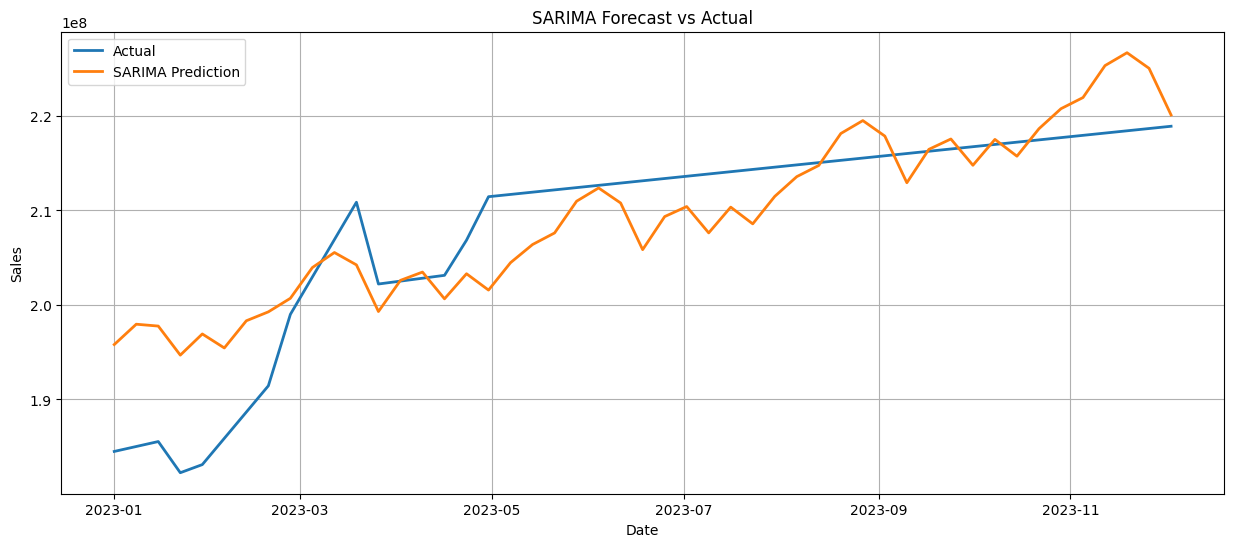

In [209]:
plt.figure(figsize=(15,6))

plt.plot(
    val_arima['Date'],
    val_arima['Total'],
    label='Actual',
    linewidth=2
)

plt.plot(
    val_arima['Date'],
    sarima_preds,
    label='SARIMA Prediction',
    linewidth=2
)

plt.title('SARIMA Forecast vs Actual')

plt.xlabel('Date')

plt.ylabel('Sales')

plt.legend()

plt.grid(True)

plt.show()

<h2>MODEL 4: LSTM</h2>

<h3>STEP 1: Scaling</h3>

In [194]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(
    state_df[['Total']]
)

<h3>STEP 2: Create Sequences</h3>

In [195]:
def create_sequences(data, seq_length=12):

    X = []
    y = []

    for i in range(len(data) - seq_length):

        X.append(data[i:i+seq_length])

        y.append(data[i+seq_length])

    return np.array(X), np.array(y)

<h4>Create Dataset</h4>

In [196]:
X_lstm, y_lstm = create_sequences(
    scaled_data,
    seq_length=12
)

<h4>Train/Test Split</h4>

In [197]:
'''
split_index = int(len(X_lstm) * 0.8)

X_train_lstm = X_lstm[:split_index]
X_val_lstm = X_lstm[split_index:]

y_train_lstm = y_lstm[:split_index]
y_val_lstm = y_lstm[split_index:] '''

In [221]:
train_lstm_df = state_df[
    state_df['Date'] < '2023-01-01'
]

val_lstm_df = state_df[
    state_df['Date'] >= '2023-01-01'
]

<h3>Fit Scaler ONLY on Train</h3>

In [222]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(
    train_lstm_df[['Total']]
)

val_scaled = scaler.transform(
    val_lstm_df[['Total']]
)

<h3>Sequence Funtion</h3>

In [223]:
def create_sequences(data, seq_length=12):

    X = []
    y = []

    for i in range(len(data) - seq_length):

        X.append(data[i:i+seq_length])

        y.append(data[i+seq_length])

    return np.array(X), np.array(y)

<h3>Create Sequences Separately</h3>

In [224]:
X_train_lstm, y_train_lstm = create_sequences(
    train_scaled
)

X_val_lstm, y_val_lstm = create_sequences(
    val_scaled
)

<h3>STEP 3: Build LSTM</h3>

In [198]:
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    LSTM,
    Dense
)

lstm_model = Sequential([
    LSTM(64, input_shape=(12,1)),
    Dense(1)
])

lstm_model.compile(
    optimizer='adam',
    loss='mse'
)


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "D:\PYTHON\envs\ml\lib\runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "D:\PYTHON\envs\ml\lib\runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "D:\PYTHON\envs\ml\lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "D:\PYTHON\envs\ml\lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "D:\PYTHON\envs\ml\lib\site-packages\ipykernel\kernelapp.py", line

AttributeError: _ARRAY_API not found

D:\PYTHON\envs\ml\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


<h3>STEP 4: Train</h3>

In [225]:
lstm_model.fit(
    X_train_lstm,
    y_train_lstm,
    epochs=20,
    batch_size=16,
    validation_data=(X_val_lstm, y_val_lstm)
)

Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0106 - val_loss: 5.3488e-04
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0105 - val_loss: 3.2582e-04
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0105 - val_loss: 4.7922e-04
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0104 - val_loss: 4.9852e-04
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0108 - val_loss: 2.2730e-04
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0103 - val_loss: 2.8113e-04
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0104 - val_loss: 3.8295e-04
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0101 - val_loss: 2.7663e-04
Epoch 9/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0101 - val_loss: 2.8002e-04
Epoch 10/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0100 - val_loss: 6.9928e-04
Epoch 11/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0100 - val_loss: 4.1324e-04
Epoch 12/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 1

<h3>STEP 5: Predict</h3>

In [226]:
lstm_preds = lstm_model.predict(
    X_val_lstm
)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


<h4>Reverse Scaling</h4>

In [227]:
lstm_preds = scaler.inverse_transform(
    lstm_preds
)

y_val_actual = scaler.inverse_transform(
    y_val_lstm.reshape(-1,1)
)

<h3>Evaluate</h3>

In [231]:
lstm_rmse = np.sqrt(
    mean_squared_error(
        y_val_actual,
        lstm_preds
    )
)

lstm_mae = mean_absolute_error(
    y_val_actual,
    lstm_preds
)

print("lstm_rmse: ", lstm_rmse)
print("lstm_MAE: ", lstm_mae)

lstm_rmse:  1852997.8147428
lstm_MAE:  1376499.4468468605


<h3>Visualization</h3>

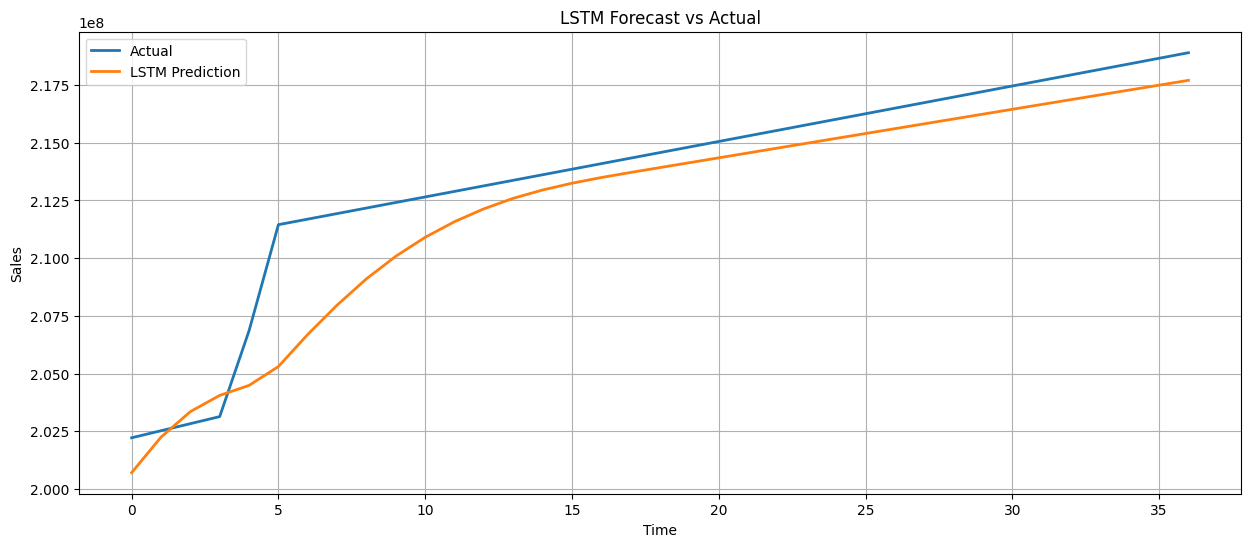

In [232]:
plt.figure(figsize=(15,6))

plt.plot(
    y_val_actual,
    label='Actual',
    linewidth=2
)

plt.plot(
    lstm_preds,
    label='LSTM Prediction',
    linewidth=2
)

plt.title('LSTM Forecast vs Actual')

plt.xlabel('Time')

plt.ylabel('Sales')

plt.legend()

plt.grid(True)

plt.show()

<h2>Combined Forcast Comparision</h2>

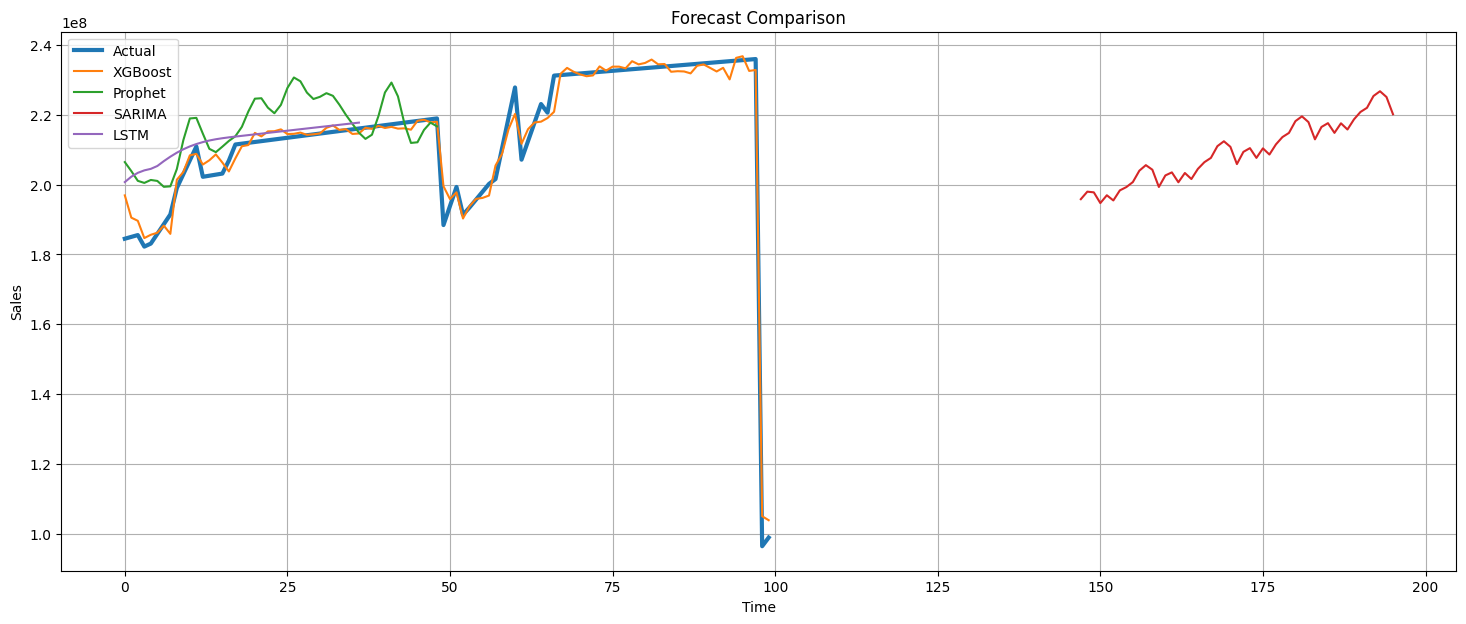

In [233]:
plt.figure(figsize=(18,7))

plt.plot(
    y_val.values[:100],
    label='Actual',
    linewidth=3
)

plt.plot(
    xgb_preds[:100],
    label='XGBoost'
)

plt.plot(
    prophet_preds[:100],
    label='Prophet'
)

plt.plot(
    sarima_preds[:100],
    label='SARIMA'
)

plt.plot(
    lstm_preds[:100],
    label='LSTM'
)

plt.title('Forecast Comparison')

plt.xlabel('Time')

plt.ylabel('Sales')

plt.legend()

plt.grid(True)

plt.show()

In [235]:
results = {
    'Model': [
        'XGBoost',
        'Prophet',
        'SARIMA',
        'LSTM'
    ],

    'RMSE': [
        rmse,
        prophet_rmse,
        sarima_rmse,
        lstm_rmse
    ],

    'MAE': [
        mae,
        prophet_mae,
        sarima_mae,
        lstm_mae
    ]
}

In [ ]:
     Model          RMSE           MAE
3     LSTM  2.122126e+06  1.198664e+06
2   SARIMA  5.944720e+06  4.581619e+06
0  XGBoost  7.183824e+06  3.265600e+06
1  Prophet  1.038997e+07  8.996129e+06

In [236]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(
    by='RMSE'
)
print(results_df)

     Model          RMSE           MAE
3     LSTM  1.852998e+06  1.376499e+06
2   SARIMA  5.944720e+06  4.581619e+06
0  XGBoost  7.183824e+06  3.265600e+06
1  Prophet  1.038997e+07  8.996129e+06


<h3>Select Best Model Automatically</h3>

In [237]:
best_model_name = results_df.iloc[0]['Model']

print("Best Model:", best_model_name)

Best Model: LSTM


<h4>Store and fetch Best Model Object</h4>

In [238]:
model_registry = {
    'XGBoost': xgb_model,
    'Prophet': prophet_model,
    'SARIMA': sarima_result,
    'LSTM': lstm_model
}
best_model = model_registry[best_model_name]

<h3>XGBoost</h3>

In [239]:
import joblib

joblib.dump(
    xgb_model,
    'xgboost_model.pkl'
)

['xgboost_model.pkl']

<h3>SARIMA</h3>

In [240]:
joblib.dump(
    sarima_result,
    'sarima_model.pkl'
)

['sarima_model.pkl']

<h3>Prophet</h3>

In [241]:
from prophet.serialize import model_to_json

with open(
    'prophet_model.json',
    'w'
) as fout:

    fout.write(
        model_to_json(prophet_model)
    )

<h3>LSTM</h3>

In [242]:
lstm_model.save(
    'lstm_model.h5'
)

<h3>Save Best Model Metadata</h3>
<p>best model name<br>
metrics<br>
features</p>

In [243]:
best_model_metadata = {
    'best_model_name': best_model_name,
    'rmse': float(results_df.iloc[0]['RMSE']),
    'mae': float(results_df.iloc[0]['MAE'])
}

<h3>Save Metadata JSON</h3>


In [244]:
import json

with open(
    'best_model_metadata.json',
    'w'
) as f:

    json.dump(
        best_model_metadata,
        f
    )

<h2>Multi-State Dynamic Forecasting System</h2>

In [266]:
best_model_registry = {}

In [267]:
forecast_registry = {}

In [268]:
metrics_registry = {}

In [269]:
states = df_final['State'].unique()

In [308]:
forecast_registry = {}

for state in states:

    print(f"Processing {state}")

    # --------------------------------
    # FILTER STATE DATA
    # --------------------------------

    state_df = df_final[
        df_final['State'] == state
    ].copy()

    # --------------------------------
    # TRAIN/VAL SPLIT
    # --------------------------------

    train_df = state_df[
        state_df['Date'] < '2023-01-01'
    ]

    val_df = state_df[
        state_df['Date'] >= '2023-01-01'
    ]

    # --------------------------------
    # LSTM SCALING
    # --------------------------------

    scaler = MinMaxScaler()

    train_scaled = scaler.fit_transform(
        train_df[['Total']]
    )

    val_scaled = scaler.transform(
        val_df[['Total']]
    )

    # --------------------------------
    # CREATE SEQUENCES
    # --------------------------------

    X_train_lstm, y_train_lstm = create_sequences(
        train_scaled
    )

    X_val_lstm, y_val_lstm = create_sequences(
        val_scaled
    )

    # --------------------------------
    # BUILD MODEL
    # --------------------------------

    lstm_model = Sequential([
        LSTM(64, input_shape=(12,1)),
        Dense(1)
    ])

    lstm_model.compile(
        optimizer='adam',
        loss='mse'
    )

    # --------------------------------
    # TRAIN MODEL
    # --------------------------------

    lstm_model.fit(
        X_train_lstm,
        y_train_lstm,
        epochs=5,
        batch_size=16,
        verbose=0
    )

    # --------------------------------
    # FORECAST NEXT 8 WEEKS
    # --------------------------------

    last_sequence = X_val_lstm[-1]

    future_preds_list = []

    current_seq = last_sequence.copy()

    for _ in range(8):

        pred = lstm_model.predict(
            current_seq.reshape(1,12,1),
            verbose=0
        )

        future_preds_list.append(pred[0][0])

        current_seq = np.append(
            current_seq[1:],
            pred
        )

    # --------------------------------
    # INVERSE TRANSFORM
    # --------------------------------

    future_preds_array = scaler.inverse_transform(
        np.array(
            future_preds_list
        ).reshape(-1,1)
    )

    # --------------------------------
    # CREATE FUTURE DATES
    # --------------------------------

    future_dates = pd.date_range(
        start=state_df['Date'].max(),
        periods=9,
        freq='W'
    )[1:]

    # --------------------------------
    # FINAL FORECAST DATAFRAME
    # --------------------------------

    future_preds = pd.DataFrame({

        'Date': future_dates,

        'Forecast': future_preds_array.flatten()
    })

    # --------------------------------
    # STORE FORECAST
    # --------------------------------

    forecast_registry[state] = future_preds

    print(future_preds.head())

    print("-" * 50)





# for state in states:

#     print(f"Processing {state}")

#     # train models
#     # compare metrics
#     # generate forecast

#     forecast_registry[state] = future_preds
#     print(state)
#     print(future_preds.head())
#     print("-" * 50)

#     best_model_registry[state] = {
#         'model_name': best_model_name,
#         'model_object': model_registry[best_model_name]
#     }

#     metrics_registry[state] = results_df

Processing Alabama


D:\PYTHON\envs\ml\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


        Date     Forecast
0 2023-12-10  220716048.0
1 2023-12-17  221119840.0
2 2023-12-24  221571776.0
3 2023-12-31  222052432.0
4 2024-01-07  222550880.0
--------------------------------------------------
Processing Arizona


D:\PYTHON\envs\ml\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


        Date     Forecast
0 2023-12-10  232280320.0
1 2023-12-17  232307920.0
2 2023-12-24  232205504.0
3 2023-12-31  232004880.0
4 2024-01-07  231741456.0
--------------------------------------------------
Processing Arkansas


D:\PYTHON\envs\ml\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


        Date     Forecast
0 2023-12-10  118310568.0
1 2023-12-17  118666928.0
2 2023-12-24  119071032.0
3 2023-12-31  119507456.0
4 2024-01-07  119965744.0
--------------------------------------------------
Processing California


D:\PYTHON\envs\ml\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


        Date     Forecast
0 2023-12-10  921768960.0
1 2023-12-17  923114944.0
2 2023-12-24  924448384.0
3 2023-12-31  925763776.0
4 2024-01-07  927057600.0
--------------------------------------------------
Processing Colorado


D:\PYTHON\envs\ml\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


        Date     Forecast
0 2023-12-10  188576592.0
1 2023-12-17  189007312.0
2 2023-12-24  189477152.0
3 2023-12-31  189964912.0
4 2024-01-07  190463504.0
--------------------------------------------------
Processing Connecticut


D:\PYTHON\envs\ml\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


        Date    Forecast
0 2023-12-10  91477720.0
1 2023-12-17  91476648.0
2 2023-12-24  91379928.0
3 2023-12-31  91208680.0
4 2024-01-07  90987664.0
--------------------------------------------------
Processing Florida


D:\PYTHON\envs\ml\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


        Date     Forecast
0 2023-12-10  825027904.0
1 2023-12-17  827096832.0
2 2023-12-24  828939776.0
3 2023-12-31  830651008.0
4 2024-01-07  832258688.0
--------------------------------------------------
Processing Georgia


D:\PYTHON\envs\ml\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


        Date     Forecast
0 2023-12-10  410650816.0
1 2023-12-17  411396448.0
2 2023-12-24  412270496.0
3 2023-12-31  413215072.0
4 2024-01-07  414202368.0
--------------------------------------------------
Processing Illinois


D:\PYTHON\envs\ml\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


        Date     Forecast
0 2023-12-10  331609728.0
1 2023-12-17  331816832.0
2 2023-12-24  331444608.0
3 2023-12-31  330799104.0
4 2024-01-07  329979904.0
--------------------------------------------------
Processing Indiana


D:\PYTHON\envs\ml\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


        Date     Forecast
0 2023-12-10  239340304.0
1 2023-12-17  240126256.0
2 2023-12-24  241067536.0
3 2023-12-31  242094176.0
4 2024-01-07  243170928.0
--------------------------------------------------
Processing Iowa


D:\PYTHON\envs\ml\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


        Date     Forecast
0 2023-12-10  120091200.0
1 2023-12-17  120177976.0
2 2023-12-24  120330304.0
3 2023-12-31  120516536.0
4 2024-01-07  120724168.0
--------------------------------------------------
Processing Kansas


D:\PYTHON\envs\ml\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


        Date    Forecast
0 2023-12-10  94562216.0
1 2023-12-17  94671328.0
2 2023-12-24  94826008.0
3 2023-12-31  95009792.0
4 2024-01-07  95211832.0
--------------------------------------------------
Processing Kentucky


D:\PYTHON\envs\ml\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


        Date     Forecast
0 2023-12-10  184716320.0
1 2023-12-17  184984704.0
2 2023-12-24  185355488.0
3 2023-12-31  185770640.0
4 2024-01-07  186211088.0
--------------------------------------------------
Processing Louisiana


D:\PYTHON\envs\ml\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


        Date     Forecast
0 2023-12-10  191730464.0
1 2023-12-17  191822912.0
2 2023-12-24  191695584.0
3 2023-12-31  191435296.0
4 2024-01-07  191097440.0
--------------------------------------------------
Processing Maine


D:\PYTHON\envs\ml\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


        Date    Forecast
0 2023-12-10  49281016.0
1 2023-12-17  49358952.0
2 2023-12-24  49449628.0
3 2023-12-31  49548360.0
4 2024-01-07  49651792.0
--------------------------------------------------
Processing Maryland


D:\PYTHON\envs\ml\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


        Date     Forecast
0 2023-12-10  169823520.0
1 2023-12-17  170073424.0
2 2023-12-24  170147408.0
3 2023-12-31  170094272.0
4 2024-01-07  169956816.0
--------------------------------------------------
Processing Massachusetts


D:\PYTHON\envs\ml\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


        Date     Forecast
0 2023-12-10  192589168.0
1 2023-12-17  192844096.0
2 2023-12-24  192863872.0
3 2023-12-31  192762800.0
4 2024-01-07  192585888.0
--------------------------------------------------
Processing Michigan


D:\PYTHON\envs\ml\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


        Date     Forecast
0 2023-12-10  314732160.0
1 2023-12-17  315786144.0
2 2023-12-24  316993024.0
3 2023-12-31  318283136.0
4 2024-01-07  319630944.0
--------------------------------------------------
Processing Minnesota


D:\PYTHON\envs\ml\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


        Date     Forecast
0 2023-12-10  163482208.0
1 2023-12-17  163826448.0
2 2023-12-24  164262208.0
3 2023-12-31  164744864.0
4 2024-01-07  165261952.0
--------------------------------------------------
Processing Mississippi


D:\PYTHON\envs\ml\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


        Date     Forecast
0 2023-12-10  127805560.0
1 2023-12-17  127814840.0
2 2023-12-24  127744448.0
3 2023-12-31  127628784.0
4 2024-01-07  127485640.0
--------------------------------------------------
Processing Missouri


D:\PYTHON\envs\ml\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


        Date     Forecast
0 2023-12-10  193998544.0
1 2023-12-17  193792560.0
2 2023-12-24  193293776.0
3 2023-12-31  192679248.0
4 2024-01-07  191992144.0
--------------------------------------------------
Processing Nebraska


D:\PYTHON\envs\ml\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


        Date    Forecast
0 2023-12-10  63900864.0
1 2023-12-17  63883832.0
2 2023-12-24  63907664.0
3 2023-12-31  63951328.0
4 2024-01-07  64007508.0
--------------------------------------------------
Processing Nevada


D:\PYTHON\envs\ml\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


        Date     Forecast
0 2023-12-10  101159240.0
1 2023-12-17  101351224.0
2 2023-12-24  101037184.0
3 2023-12-31  100484240.0
4 2024-01-07   99802328.0
--------------------------------------------------
Processing New Hampshire


D:\PYTHON\envs\ml\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


        Date    Forecast
0 2023-12-10  59097324.0
1 2023-12-17  59231912.0
2 2023-12-24  59380896.0
3 2023-12-31  59539096.0
4 2024-01-07  59702600.0
--------------------------------------------------
Processing New Mexico


D:\PYTHON\envs\ml\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


        Date    Forecast
0 2023-12-10  77806568.0
1 2023-12-17  77921792.0
2 2023-12-24  78037848.0
3 2023-12-31  78153624.0
4 2024-01-07  78268424.0
--------------------------------------------------
Processing New York


D:\PYTHON\envs\ml\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


        Date     Forecast
0 2023-12-10  457768384.0
1 2023-12-17  458440672.0
2 2023-12-24  458926560.0
3 2023-12-31  459307392.0
4 2024-01-07  459614848.0
--------------------------------------------------
Processing North Carolina


D:\PYTHON\envs\ml\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


        Date     Forecast
0 2023-12-10  376600736.0
1 2023-12-17  376553088.0
2 2023-12-24  376323392.0
3 2023-12-31  375964320.0
4 2024-01-07  375526048.0
--------------------------------------------------
Processing Ohio


D:\PYTHON\envs\ml\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


        Date     Forecast
0 2023-12-10  397655904.0
1 2023-12-17  398227008.0
2 2023-12-24  398821632.0
3 2023-12-31  399431232.0
4 2024-01-07  400048544.0
--------------------------------------------------
Processing Oklahoma


D:\PYTHON\envs\ml\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


        Date     Forecast
0 2023-12-10  151094400.0
1 2023-12-17  151225920.0
2 2023-12-24  151342320.0
3 2023-12-31  151449616.0
4 2024-01-07  151550208.0
--------------------------------------------------
Processing Oregon


D:\PYTHON\envs\ml\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


        Date     Forecast
0 2023-12-10  117505992.0
1 2023-12-17  117414320.0
2 2023-12-24  117322056.0
3 2023-12-31  117230344.0
4 2024-01-07  117139736.0
--------------------------------------------------
Processing Pennsylvania


D:\PYTHON\envs\ml\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


        Date     Forecast
0 2023-12-10  385990496.0
1 2023-12-17  386797376.0
2 2023-12-24  387697248.0
3 2023-12-31  388650240.0
4 2024-01-07  389632160.0
--------------------------------------------------
Processing Rhode Island


D:\PYTHON\envs\ml\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


        Date    Forecast
0 2023-12-10  27429238.0
1 2023-12-17  27466104.0
2 2023-12-24  27513988.0
3 2023-12-31  27567542.0
4 2024-01-07  27624598.0
--------------------------------------------------
Processing South Carolina


D:\PYTHON\envs\ml\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


        Date     Forecast
0 2023-12-10  200563552.0
1 2023-12-17  200417616.0
2 2023-12-24  200032720.0
3 2023-12-31  199518736.0
4 2024-01-07  198923136.0
--------------------------------------------------
Processing South Dakota


D:\PYTHON\envs\ml\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


        Date    Forecast
0 2023-12-10  28464678.0
1 2023-12-17  28435544.0
2 2023-12-24  28375380.0
3 2023-12-31  28296548.0
4 2024-01-07  28207768.0
--------------------------------------------------
Processing Tennessee


D:\PYTHON\envs\ml\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


        Date     Forecast
0 2023-12-10  270692320.0
1 2023-12-17  270810336.0
2 2023-12-24  270869312.0
3 2023-12-31  270891968.0
4 2024-01-07  270890208.0
--------------------------------------------------
Processing Texas


D:\PYTHON\envs\ml\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


        Date     Forecast
0 2023-12-10  982394624.0
1 2023-12-17  985520128.0
2 2023-12-24  988900096.0
3 2023-12-31  992535680.0
4 2024-01-07  996324224.0
--------------------------------------------------
Processing Utah


D:\PYTHON\envs\ml\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


        Date    Forecast
0 2023-12-10  90465472.0
1 2023-12-17  90588664.0
2 2023-12-24  90774200.0
3 2023-12-31  91001464.0
4 2024-01-07  91254480.0
--------------------------------------------------
Processing Vermont


D:\PYTHON\envs\ml\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


        Date    Forecast
0 2023-12-10  18692280.0
1 2023-12-17  18715546.0
2 2023-12-24  18743890.0
3 2023-12-31  18775824.0
4 2024-01-07  18809972.0
--------------------------------------------------
Processing Virginia


D:\PYTHON\envs\ml\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


        Date     Forecast
0 2023-12-10  307490016.0
1 2023-12-17  307806208.0
2 2023-12-24  308109120.0
3 2023-12-31  308400800.0
4 2024-01-07  308682944.0
--------------------------------------------------
Processing Washington


D:\PYTHON\envs\ml\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


        Date     Forecast
0 2023-12-10  196870032.0
1 2023-12-17  196992928.0
2 2023-12-24  197284224.0
3 2023-12-31  197673024.0
4 2024-01-07  198124080.0
--------------------------------------------------
Processing West Virginia


D:\PYTHON\envs\ml\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


        Date    Forecast
0 2023-12-10  78399096.0
1 2023-12-17  78476784.0
2 2023-12-24  78560040.0
3 2023-12-31  78645000.0
4 2024-01-07  78730560.0
--------------------------------------------------
Processing Wisconsin


D:\PYTHON\envs\ml\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


        Date     Forecast
0 2023-12-10  160717120.0
1 2023-12-17  160648640.0
2 2023-12-24  160546048.0
3 2023-12-31  160425136.0
4 2024-01-07  160293296.0
--------------------------------------------------
Processing Wyoming


D:\PYTHON\envs\ml\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


        Date    Forecast
0 2023-12-10  22233288.0
1 2023-12-17  22239442.0
2 2023-12-24  22254974.0
3 2023-12-31  22275412.0
4 2024-01-07  22298862.0
--------------------------------------------------


In [309]:
train_df = state_df[
    state_df['Date'] < '2023-01-01'
]

val_df = state_df[
    state_df['Date'] >= '2023-01-01'
]

In [310]:
results = {
    'Model': [
        'XGBoost',
        'Prophet',
        'SARIMA',
        'LSTM'
    ],

    'RMSE': [
        rmse,
        prophet_rmse,
        sarima_rmse,
        lstm_rmse
    ],

    'MAE': [
        mae,
        prophet_mae,
        sarima_mae,
        lstm_mae
    ]
}

In [311]:
results_df = pd.DataFrame(results)

In [312]:
results_df = results_df.sort_values(
    by='RMSE'
)

In [313]:
best_model_name = results_df.iloc[0]['Model']

In [314]:
model_registry = {
    'XGBoost': xgb_model,
    'Prophet': prophet_model,
    'SARIMA': sarima_result,
    'LSTM': lstm_model
}

In [315]:
best_model_registry[state] = {
    'model_name': best_model_name
    # ,'model_object': model_registry[best_model_name]
}

Prophet

In [316]:
if best_model_name == 'Prophet':

    future = prophet_model.make_future_dataframe(
        periods=8,
        freq='W'
    )

    forecast = prophet_model.predict(future)

    future_preds = forecast.tail(8)[
        ['ds', 'yhat']
    ]
elif best_model_name == 'SARIMA':

    preds = sarima_result.forecast(
        steps=8
    )

    future_dates = pd.date_range(
        start=state_df['Date'].max(),
        periods=9,
        freq='W'
    )[1:]

    future_preds = pd.DataFrame({
        'Date': future_dates,
        'Forecast': preds.values
    })
elif best_model_name == 'LSTM':

    last_sequence = X_val_lstm[-1]

    future_preds_list = []

    current_seq = last_sequence.copy()

    for _ in range(8):

        pred = lstm_model.predict(
            current_seq.reshape(1,12,1),
            verbose=0
        )

        future_preds_list.append(pred[0][0])

        current_seq = np.append(
            current_seq[1:],
            pred
        )

    future_preds_array = scaler.inverse_transform(
        np.array(
            future_preds_list
        ).reshape(-1,1)
    )

    future_dates = pd.date_range(
        start=state_df['Date'].max(),
        periods=9,
        freq='W'
    )[1:]

    future_preds = pd.DataFrame({
        'Date': future_dates,
        'Forecast': future_preds_array.flatten()
    })

In [317]:
forecast_registry[state] = future_preds
print(
    forecast_registry['Texas']
)

        Date      Forecast
0 2023-12-10  9.823946e+08
1 2023-12-17  9.855201e+08
2 2023-12-24  9.889001e+08
3 2023-12-31  9.925357e+08
4 2024-01-07  9.963242e+08
5 2024-01-14  1.000202e+09
6 2024-01-21  1.004129e+09
7 2024-01-28  1.008077e+09


<h3>Save Best Model Registry</h3>

In [318]:
joblib.dump(
    best_model_registry,
    'best_model_registry.pkl'
)

['best_model_registry.pkl']

<h3>Save Forcast Registry</h3>

In [319]:
joblib.dump(
    forecast_registry,
    'forecast_registry.pkl'
)

['forecast_registry.pkl']

<h3>Save Metrics Registry</h3>

In [320]:
joblib.dump(
    metrics_registry,
    'metrics_registry.pkl'
)

['metrics_registry.pkl']

In [300]:
import os

print(os.listdir())

['.ipynb_checkpoints', 'best_model_metadata.json', 'best_model_registry.pkl', 'Data_processed_file.xlsx', 'df_final.xlsx', 'df_year.xlsx', 'EDA.ipynb', 'Forecasting Case- Study.xlsx', 'forecast_registry.pkl', 'lstm_model.h5', 'metrics_registry.pkl', 'prophet_model.json', 'sarima_model.pkl', 'xgboost_model.pkl', '~$Data_processed_file.xlsx', '~$df_final.xlsx', '~$Forecasting Case- Study.xlsx']


<h4>Load Back</h4>

In [301]:
loaded_metrics = joblib.load(
    'metrics_registry.pkl'
)

<h4>Inspecting</h4>

In [302]:
print(loaded_metrics.keys())

dict_keys(['Alabama', 'Arizona', 'Arkansas', 'California', 'Colorado', 'Connecticut', 'Florida', 'Georgia', 'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana', 'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota', 'Mississippi', 'Missouri', 'Nebraska', 'Nevada', 'New Hampshire', 'New Mexico', 'New York', 'North Carolina', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania', 'Rhode Island', 'South Carolina', 'South Dakota', 'Tennessee', 'Texas', 'Utah', 'Vermont', 'Virginia', 'Washington', 'West Virginia', 'Wisconsin', 'Wyoming'])


In [303]:
print(
    loaded_metrics['Maine']
)

     Model          RMSE           MAE
3     LSTM  1.852998e+06  1.376499e+06
2   SARIMA  5.944720e+06  4.581619e+06
0  XGBoost  7.183824e+06  3.265600e+06
1  Prophet  1.038997e+07  8.996129e+06


In [305]:
from tensorflow.keras.models import load_model

lstm_model = load_model(
    'lstm_model.h5',
    compile=False
)

In [306]:
forecast_registry = joblib.load(
    'forecast_registry.pkl'
)

best_model_registry = joblib.load(
    'best_model_registry.pkl'
)

D:\PYTHON\envs\ml\lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 7 variables whereas the saved optimizer has 12 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


<h2>FastAPI Forecasting Service</h2>

In [57]:
df.to_excel("df_year.xlsx",sheet_name="new_df",index=False)

In [60]:
df.date.dt.month.unique()

array([ 1,  3,  6,  8, 10,  2,  4,  5,  7,  9, 11, 12], dtype=int32)

In [58]:
df.Year.unique()

array([2019, 2020, 2021, 2022, 2023], dtype=int32)

In [54]:
df[df['Year']==2019]

,State,Total,Category,date,Year
0,Alabama,109574036.0,Beverages,2019-01-12,2019
1,Arizona,109101594.6,Beverages,2019-01-12,2019
2,Arkansas,58049432.2,Beverages,2019-01-12,2019
3,California,444766890.6,Beverages,2019-01-12,2019
4,Colorado,89816716.3,Beverages,2019-01-12,2019
...,...,...,...,...,...
7692,Virginia,151352892.8,Beverages,2019-12-29,2019
7693,Washington,100706539.0,Beverages,2019-12-29,2019
7694,West Virginia,37371772.0,Beverages,2019-12-29,2019
7695,Wisconsin,86541497.0,Beverages,2019-12-29,2019


In [10]:
df['Month']=df.date.dt.month

In [12]:
df.columns

Index(['State', 'Total', 'Category', 'date', 'Year', 'Month'], dtype='object')

In [14]:
df.head()

,State,Total,Category,date,Year,Month
0,Alabama,109574036.0,Beverages,2019-01-12,2019,1
1,Arizona,109101594.6,Beverages,2019-01-12,2019,1
2,Arkansas,58049432.2,Beverages,2019-01-12,2019,1
3,California,444766890.6,Beverages,2019-01-12,2019,1
4,Colorado,89816716.3,Beverages,2019-01-12,2019,1


In [17]:
df['date'].sort_values().diff().value_counts()

date
0 days     7896
7 days       81
3 days       15
9 days       14
5 days       11
8 days       11
1 days        6
2 days        5
12 days       5
4 days        5
6 days        5
14 days       4
11 days       4
21 days       4
10 days       4
13 days       3
63 days       2
91 days       1
58 days       1
60 days       1
16 days       1
15 days       1
27 days       1
34 days       1
89 days       1
Name: count, dtype: int64

In [48]:
value = []
for i in (df.date[df['date'].dt.year == 2022].unique()):
    value.append(i)
print(value)

[Timestamp('2022-01-05 00:00:00'), Timestamp('2022-02-01 00:00:00'), Timestamp('2022-02-10 00:00:00'), Timestamp('2022-03-04 00:00:00'), Timestamp('2022-03-07 00:00:00'), Timestamp('2022-04-09 00:00:00'), Timestamp('2022-04-12 00:00:00'), Timestamp('2022-05-06 00:00:00'), Timestamp('2022-06-02 00:00:00'), Timestamp('2022-06-03 00:00:00'), Timestamp('2022-06-11 00:00:00'), Timestamp('2022-07-08 00:00:00'), Timestamp('2022-08-05 00:00:00'), Timestamp('2022-09-01 00:00:00'), Timestamp('2022-09-10 00:00:00'), Timestamp('2022-10-04 00:00:00'), Timestamp('2022-10-07 00:00:00'), Timestamp('2022-11-09 00:00:00'), Timestamp('2022-11-12 00:00:00'), Timestamp('2022-12-06 00:00:00'), Timestamp('2022-02-13 00:00:00'), Timestamp('2022-03-13 00:00:00'), Timestamp('2022-11-13 00:00:00'), Timestamp('2022-08-14 00:00:00'), Timestamp('2022-05-15 00:00:00'), Timestamp('2022-01-16 00:00:00'), Timestamp('2022-10-16 00:00:00'), Timestamp('2022-04-17 00:00:00'), Timestamp('2022-07-17 00:00:00'), Timestamp('20

In [49]:
value.sort()

In [53]:
for i in range(1, len(value)):
    print(value[i], (value[i]-value[i-1]).days)

2022-01-16 00:00:00 11
2022-01-23 00:00:00 7
2022-01-30 00:00:00 7
2022-02-01 00:00:00 2
2022-02-10 00:00:00 9
2022-02-13 00:00:00 3
2022-02-20 00:00:00 7
2022-02-27 00:00:00 7
2022-03-04 00:00:00 5
2022-03-07 00:00:00 3
2022-03-13 00:00:00 6
2022-03-20 00:00:00 7
2022-03-27 00:00:00 7
2022-04-09 00:00:00 13
2022-04-12 00:00:00 3
2022-04-17 00:00:00 5
2022-04-24 00:00:00 7
2022-05-06 00:00:00 12
2022-05-15 00:00:00 9
2022-05-22 00:00:00 7
2022-05-29 00:00:00 7
2022-06-02 00:00:00 4
2022-06-03 00:00:00 1
2022-06-11 00:00:00 8
2022-06-19 00:00:00 8
2022-06-26 00:00:00 7
2022-07-08 00:00:00 12
2022-07-17 00:00:00 9
2022-07-24 00:00:00 7
2022-07-31 00:00:00 7
2022-08-05 00:00:00 5
2022-08-14 00:00:00 9
2022-08-21 00:00:00 7
2022-08-28 00:00:00 7
2022-09-01 00:00:00 4
2022-09-10 00:00:00 9
2022-09-18 00:00:00 8
2022-09-25 00:00:00 7
2022-10-04 00:00:00 9
2022-10-07 00:00:00 3
2022-10-16 00:00:00 9
2022-10-23 00:00:00 7
2022-10-30 00:00:00 7
2022-11-09 00:00:00 10
2022-11-12 00:00:00 3
2022-